# **Esame del 25 luglio 2024**

- Non si possono consultare libri, note, ed ogni altro materiale o persone durante
l’esame ad eccezione delle funzioni Python fornite.

- Risolvere i seguenti esercizi con l’ausilio di Python.

- La durata del compito è di 90 minuti.

- Questo esame ha 3 domande, per un totale di 30/30 punti + 1 extra.

- Svolgere gli esercizi marcati con **[T]** su fogli protocollo, indicando: nome, cognome, codice persona
e data

# **Esercizio 1 (punti 10+1)**

Si consideri il seguente problema differenziale

\begin{gather*}
\begin{cases}
-u^{\prime\prime}(x) + 2u(x) = f(x) \quad x \in (0, 0.75)\\
u(0) = 0 \\
-u^\prime(0.75) = 0
\end{cases}
\end{gather*}

#### **(1a) (2 punti) [T]**  

Si calcoli il valore della funzione $f$ in modo tale che la $u_{\rm ex}(x) = \sin(2 \pi x)$ sia la soluzione esatta. Verificare inoltre che tale soluzione soddisfa le condizioni al bordo richieste.

In [1]:
#u_ex'=2*pi*cos(2*pi*x) --> cond di neumann verificata
#u(0)=sen(0)=0 --> con dirichlet verificata

#u_ex''=-4*pi^2*sen(2*pi*x)
#sostituendo:
# 4*pi^2*sen(2*pi*x)+2*sen(2*pi*x)=f(x)=(4*pi^2+2)sen(2*pi*x)

##### **Soluzione.**

Anzitutto, verifichiamo che la soluzione esatta soddisfa le condizioni al bordo, per la condizione di Neumann devo calcolare la derivata di $u_{\rm ex}$
\begin{gather*}
u^{\prime}_{\rm ex}(x) = 2 \pi \cos(2\pi x)
\end{gather*}
verifichiamo ora le due condizioni ai bordi
\begin{gather*}
u_{\rm ex}(0) = \sin(2\pi 0) = 0\\
-u^{\prime}_{ex}(0.75) = 2 \pi \cos\left(2 \pi \frac{3}{4}\right) = 2 \pi \cos\left(\frac{3}{2}\pi\right) = 0
\end{gather*}
effettivamente la soluzione esatta soddisfa le condizioni ai bordi. Determiniamo ora la funzione $f$, per farlo dobbiamo calcolare la derivata seconda di $u_{\rm ex}$
\begin{gather*}
u^{\prime\prime}_{\rm ex}(x) = -4 \pi^2 \sin(2\pi x)
\end{gather*}
quindi la funzione $f$ risulta
\begin{gather*}
f(x) = -u^{\prime\prime}_{\rm ex} + 2 u_{\rm ex} = 4 \pi^2 \sin(2\pi x) + 2 \sin(2\pi x) = (4 \pi^2 + 2) \sin(2 \pi x)
\end{gather*}

#### **(1b) (4 punti) [T]**  

Introdurre il problema debole e la sua formulazione di Galerkin per il problema in considerazione.

In [2]:
#per scrivere il problema in forma debole dobbiamo moltiplicare l'equazione differenziale per una funzione test appartenente allo spazio
#V=spazio delle funzioni appartenenti allo spazio di sobolev H1(0,0.75) tc v(0)=0. e poi dobbiamo integrare l'equazione tra 0 e 0.75
#Introduciamo quindi una forma bilineare e un funzionale lineare. il problema debole sarà: trovaare u appartenente a V tc a(u,v)=F(v) per 
#ogni v appartenente a V

#la formulazione di Galerkin è la discretizzazione del problema enunciato e prevede di considerare un sottospazio di V finito dimensionale, Vh.
# Essendo Vh finito dimensionale, possiamo introdurre una sua base ed esprimere le funzioni appartenenti a tale spazio come span della base. 
#Come base prendiamo le funzioni a capanna (polinomi di Lagrange).
#la formulazione nello spazio Vh diventa: trovare uh tc a(uh, vh)=F(vh) per ogni vh appartenente a Vh. 
#possiamo espandere uh e vh sulla base e poi sostituire nell'equazione. 
#dopo aver sostituito vh nell'equazione di partenza avremo: a(uh, phi_i)=F(phi_i)
#possiamo poi sostuituire anche uh=somma(uj*phi_j) --> sommauj*a(phi_j,phi_i)=F(phi_i), dove uj sono detti gradi di libertà della soluzione
#in questo modo l'equazione iniziale diventa un sistema lineare in Nh equazioni: Au=f --> ho trasformato un problema con infinite equazioni in un 
#sistema lineare che so risolvere

##### **Soluzione.**

Per presentare la formulazione debole del problema, introduciamo anzitutto lo spazio funzionale $V$
\begin{gather*}
V = \{v \in H^1(0, 0.75): v(0) = 0\}
\end{gather*}
procediamo quindi alla formulazione debole del problema
\begin{gather*}
\int_0^{0.75}-u^{\prime\prime}v + \int_0^{0.75} 2 u v = \int_0^{0.75} u^\prime v^\prime - [u^{\prime} v]_0^{0.75} + \int_0^{0.75} 2 u v
\end{gather*}
il termine di bordo si annulla in $0$ dato che richiediamo $v\in V$ e si annulla anche in $0.75$ dato che $-u^\prime(0.75) = 0$.
La formulazione debole del problema quindi richiede di introdurre la forma $a$ e il funzionale $F$ seguenti
\begin{gather*}
a(u, v) =  \int_0^{0.75} u^\prime v^\prime + \int_0^{0.75} 2 u v \qquad F(v) = \int_0^{0.75} f v
\end{gather*}
e quindi il problema debole risulta: trovare $u \in V$ tale che
\begin{gather*}
a(u, v) = F(v)\qquad \forall v \in V
\end{gather*}

Il metodo di Galerkin costruisce un sottospazio $V_h$ finito dimensionale di $V$
tale per cui per $h\rightarrow 0$ allora $V_h \rightarrow V$, dove appunto $h$
è il passo di griglia o comunque un parametro legato alla discretizzazione.

Scelto quindi uno spazio $V_h$, introduciamo ora la formulazione di Galerkin del problema visto
precedentemente, che consiste nel trovare $u_h \in V_h$ tale che
\begin{gather*}%\label{eq:gal}
    a(u_h, v_h) = F(v_h) \quad \forall v_h \in V_h
\end{gather*}
Essendo $v_h$ e $u_h$ elementi di $V_h$ allora
possiamo espanderli sulla base introdotta e scriverli come
\begin{gather*}
    v_h (x) = \sum_{i=1}^{N_h} \alpha_i \phi_i(x)
    \quad \text{e} \quad
    u_h (x) = \sum_{j=1}^{N_h} u_j \phi_j (x),
\end{gather*}
dove $\alpha_i \in \mathbb{R}$ e $u_j \in \mathbb{R}$ per ogni $i$ e $j=1,
\ldots, N_h$.
Sostituendo l'espressione di $v_h$ nell'equazione vista precedentemente e
sfruttando la linearità nel secondo argomento di $a$ e la linearità di $F$
otteniamo
\begin{gather*}
    a(u_h, v_h) = F(v_h)
    \quad\rightarrow \quad
    a\left(u_h, \sum_{i=1}^{N_h} \alpha_i \phi_i\right) =
    F\left(\sum_{i=1}^{N_h} \alpha_i \phi_i\right)\\
    \sum_{i=1}^{N_h} \alpha_i a\left(u_h, \phi_i\right) =
    \sum_{i=1}^{N_h} \alpha_i F\left(\phi_i\right),
\end{gather*}
ma, dato che tale relazione deve valere per tutti i $v_h \in V_h$, questo implica che deve valere
\begin{gather*}
    a\left(u_h, \phi_i\right) =
    F\left(\phi_i\right)
    \quad \forall i=1,\ldots,N_h.
\end{gather*}

Il sistema è ora formato da $N_h$ equazioni e non più un numero
infinito come visto precedentemente. Inoltre, come detto, anche la soluzione discreta $u_h$ può essere scritta data la base
$\{\phi_i\}$ nel seguente modo
\begin{gather*}
    u_h(x) = \sum_{j=1}^{N_h} u_j \phi_j(x)
\end{gather*}
dove $u_j$ sono ora coefficienti da determinare. A questo punto infatti
determinare la soluzione numerica $u_h$ equivale a
determinare i valori $\{u_j\}$, detti anche gradi di libertà, dato che le $\phi_j$ sono note (saranno definite più precisamente in seguito)
\begin{gather*}
    u_h(x) = \sum_{i=1}^{N_h} u_j \phi_j(x) \quad \xrightarrow{\text{è definita dal vettore}} \quad {u} = [u_1, \ldots, u_{N_h}]^\top.
\end{gather*}
Sostituiamo nell'espressione precedente l'espansione di $u_h$ sulla base di
$V_h$ per ottenere
\begin{gather*}
    a\left(u_h, \phi_i\right) =
    F\left(\phi_i\right)
    \quad \forall i=1,\ldots,N_h
    \quad \rightarrow \quad
    a\left(\sum_{i=1}^{N_h} u_j \phi_j, \phi_i\right) =
    F\left(\phi_i\right)
    \quad \forall i=1,\ldots,N_h
\end{gather*}
e dalla bi-linearità della forma $a$ otteniamo che
\begin{gather*}
    \sum_{i=1}^{N_h} u_j a\left(\phi_j, \phi_i\right) =
    F\left(\phi_i\right)
    \quad \forall i=1,\ldots,N_h.
\end{gather*}
Il problema discreto precedente viene scritto ora come la risoluzione di un
problema lineare, detto problema algebrico equivalente, ovvero trovare ${u}$ tale che
\begin{gather*}
    A {u} = {f}.
\end{gather*}

#### **(1c) (4 punti) [P]**  

Risolvere il problema utilizzando gli elementi finiti lineari per $h=0.01$, rappresentare graficamente la soluzione ottenuta confrontandola con la soluzione esatta.

Anzitutto importiamo alcuni moduli standard per la risoluzione dell'esercizio.

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.sparse as sps
from scipy.sparse.linalg import eigs
from fem import *

install()

ModuleNotFoundError: No module named 'fenics'

Utilizzare il seguente scipt parzialmente completo come traccia per risolvere l'esercizio, in particolare dove è indicato con `# TODO`.

In [ ]:
domain = Line(0, 0.75)
mesh = generate_mesh(domain, stepsize=0.01)
V = FEspace(mesh, 1)

f = lambda x: (4+np.pi**2+2)*np.sin(2*np.pi*x)
fh = interpolate(f, V)


def l(v):
    return 


def a(u, v):
    return ...  # TODO


# Assembla la matrice e il termine noto
A = assemble(a, V)
F = assemble(l, V)

# Valuta la condizione al bordo e applicala alla matrice A e vettore F
...  # TODO

A = applyBCs(A, V, dbc)
F = applyBCs(F, V, dbc)

# Risolvi il sistema lineare e reinterpreta la soluzione come funzione
u = sps.linalg.spsolve(A, F)
u = dof2fun(u, V)

# Rappresentazione grafica della soluzione
...  # TODO

TypeError: unsupported operand type(s) for +: 'ellipsis' and 'float'

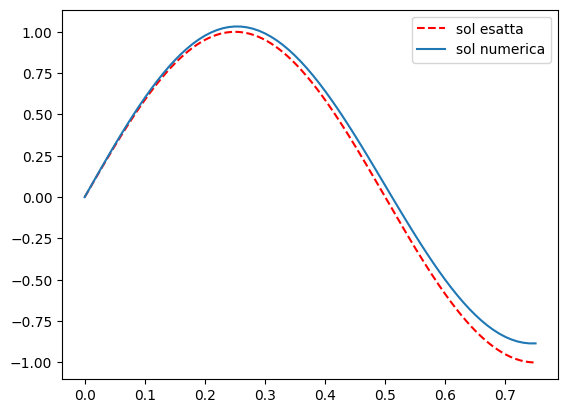

In [19]:
from fem_utils_lez import *
import numpy as np
import matplotlib.pyplot as plt

a, b= 0, 0.75
h=0.01
Nele=int((b-a)/h)

grid=Grid(a,b,Nele)
grid.compute_geometry()

f=lambda x:(4*np.pi**2 + 2)*np.sin(2*np.pi*x)
f_dofs=fun2dof(grid, f)

A_diff=diffusion(grid)
A_reac=mass(grid)
alpha=1
beta=2
A=alpha*A_diff + beta*A_reac
M=mass(grid)
F=M@f_dofs
F[-1]=0

dirichlet_nodes=[0]
dirichlet_values=[0]
bc_values=np.zeros(Nele+1)
bc_values[dirichlet_nodes]=dirichlet_values

keep_dof=np.ones(Nele+1, dtype=bool)
keep_dof[dirichlet_nodes]=False
R= create_restriction(keep_dof)


A_0= R @ A @ R.T
F_0= R @ (F-A @bc_values)
u_0=np.linalg.solve(A_0, F_0)
u=R.T @ u_0 + bc_values


u_ex=lambda x: np.sin(2*np.pi*x)
x_grid=np.linspace(0, 0.75, 1000)
plt.figure()
plt.plot(x_grid, u_ex(x_grid), '--r', label='sol esatta')
plt.plot(grid.nodes, u, label='sol numerica')
plt.legend()
plt.show()


##### **Soluzione.**

Il codice per generare la soluzione è il seguente

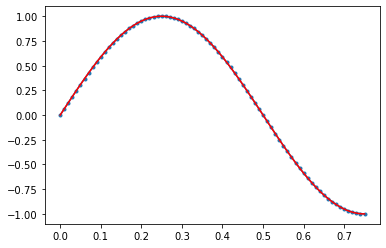

In [10]:
domain = Line(0, 0.75)
mesh = generate_mesh(domain, stepsize=0.01)
V = FEspace(mesh, 1)

f = lambda x: (4 * np.pi**2 + 2) * np.sin(2 * np.pi * x)
fh = interpolate(f, V)


def l(v):
    return fh * v * dx


def a(u, v):
    return deriv(u) * deriv(v) * dx + 2 * u * v * dx


# Assembla la matrice e il termine noto
A = assemble(a, V)
F = assemble(l, V)


# Valuta la condizione al bordo e applicala alla matrice A e vettore F
def is_left(x):
    return np.isclose(x, 0)


dbc = DirichletBC(is_left, 0.0)
A = applyBCs(A, V, dbc)
F = applyBCs(F, V, dbc)

# Risolvi il sistema lineare e reinterpreta la soluzione come funzione
u = sps.linalg.spsolve(A, F)
u = dof2fun(u, V)

# Rappresentazione grafica della soluzione
plot(u, marker=".")

xplot = np.linspace(0, 0.75, 100)
uex = lambda x: np.sin(2 * np.pi * x)

plt.plot(xplot, uex(xplot), color="red")

#### **(1d) (1 punto - extra) [T+P]**

Mostrare, con un metodo a scelta, che la forma bilineare $a$ è coerciva, e di conseguenza il sistema lineare associato ammette un'unica soluzione.

##### **Soluzione.**

Mostriamo che la forma bilineare è coerciva: 

\begin{gather*}
a(u,u) =  \int_0^{0.75} u^\prime u^\prime + \int_0^{0.75} 2 u u \geq \int_0^{0.75} u^\prime u^\prime + u^2 = \|u\|^2_V
\end{gather*}


Il problema risulta risolubile in quanto la forma bilineare $a$ è coerciva e questo implica che la matrice $A$ è definita positiva, infatti
considerando la generica coppia
$(\lambda, {v})$ di autovalore e associato autovettore a norma unitaria
abbiamo infatti
\begin{gather*}
    A {v} = \lambda {v}
    \quad \Rightarrow \quad
    {v}^\top A {v} = \lambda \Vert{{v}} \Vert^2
    \quad \Rightarrow \quad
    {v}^\top A {v} = \lambda.
\end{gather*}
Una generica funzione $v$ può essere espressa sulla base come
\begin{gather*}
    v(x) = \sum_{i=1}^{N_h} v_i \phi_i(x)
\end{gather*}
dove $v_i$ è la componente $i$-esima del vettore ${v}$. Dato che $a$ è coeciva abbiamo che per una qualsiasi funzione $v$, corrispondente al vettore ${v}$,
\begin{gather*}
    {v}^\top A {v} = a(v, v) \geq \alpha \Vert{v}\Vert_V^2 > 0\quad  \forall v \neq 0
\end{gather*}
implicando quindi che $\lambda > 0$, ovvero che $A$ è definita positiva.

# **Esercizio 2 (10 punti)**


Si consideri il seguente problema di Cauchy
\begin{gather*}
\begin{cases}
    y^{\prime}(t) = -2y(t)^2 + \dfrac{1}{1+t^2}
    \quad t \in (0, 5]\\
    y(0) = 0
    \end{cases}
\end{gather*}
dove la soluzione esatta è data da
\begin{gather*}
y(t) = \frac{t}{1+t^2}
\end{gather*}


#### **(2a) (3 punti) [T]**

Introdurre il $\theta$-metodo per la risoluzione di un problema di Cauchy generale, applicarlo quindi al problema in questione. Specificare per quali valori di $\theta$ si ottengono i metodi di Eulero implicito e Eulero esplicito e dettagliare le loro proprietà di convergenza.

In [20]:
#il theta metodo è una generalizzazione dei metodi di risoluzione dei pdc ed è dato dalla seguente espressione:
# u_n+1=u_n + h*[theta*f(t_n+1,u_n+1)+ (1-theta)*f(t_n, u_n)] con theta compreso tra 0 e 1
#in particolare theta=0 --> EULERO ESPLICITO
#theta=0,5 --> CRANK-NICHOLSON
#theta=1 --> EULERO IMPLICITO

#il theta metodo ha ordine di convergenza 1

##### **Soluzione.**

Chiamiamo $\theta$-metodo uno schema che ha questa espressione,
\begin{gather*}
    \begin{cases}
        u_{n+1} =  u_n + h [\theta f(t_{n+1}, u_{n+1}) + (1-\theta) f(t_{n}, u_{n})  ] \\
        u_0 = \overline{y}_0
    \end{cases}
\end{gather*}
dove $\theta$ è un parametro che assume valore nell'intervallo $[0, 1]$. Per
$\theta=0$ otteniamo il metodo di Eulero in avanti, per $\theta=1$ otteniamo il
metodo di Eulero all'indietro. Entrambi i metodi sono linearmente convergenti.

#### **(2b) (3 punti) [P]**

Risolvere con il metodo di Eulero implicito e Eulero esplicito il problema discretizzando in tempo con 10 passi. Rappresentare graficamente sullo stesso grafico le soluzioni numeriche ottenute e la soluzione analitica.

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# importazione Eulero all'indietro
from utilis_ODE import eulero_indietro, eulero_avanti

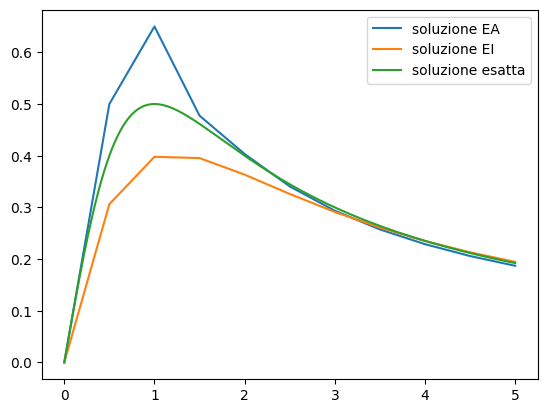

In [31]:
f=lambda t, y:  1/(1+t**2) - 2*y**2
t0, tmax=0, 5
y0=0
Nt=10
h=tmax/Nt
t_EA, u_EA= eulero_avanti(f, t0, tmax, y0, h)
t_EI, u_EI= eulero_indietro(f, t0, tmax, y0, h)

u_ex=lambda t: t/(1+t**2)
x_grid=np.linspace(0, 5, 1000)

plt.figure()
plt.plot(t_EA, u_EA, label='soluzione EA')
plt.plot(t_EI, u_EI, label='soluzione EI')
plt.plot(x_grid, u_ex(x_grid), label='soluzione esatta')
plt.legend()
plt.show()



##### **Soluzione.**

Utilizziamo il seguente codice per applicare i due metodi al problema in esame.

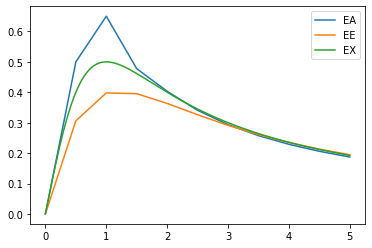

In [7]:
# creazione dei dati del problema
f = lambda t, y: 1.0 / (1 + t**2) - 2 * y * y
t0, t_max = 0, 5
y0 = 0
h = 0.5

# soluzione esatta
y = lambda t: t / (1 + t**2)
t = np.linspace(t0, t_max, 1000)

# calcolo della soluzione numerica con i due metodi
t_ea, u_ea = eulero_avanti(f, t0, t_max, y0, h)
t_ei, u_ei = eulero_indietro(f, t0, t_max, y0, h)

# plot delle soluzioni
plt.plot(t_ea, u_ea, label="EA")
plt.plot(t_ei, u_ei, label="EE")
plt.plot(t, y(t), label="EX")
plt.legend()

plt.show()

#### **(2c) (2 punti) [T]**

Si introduca il concetto di assoluta stabilità per un metodo numerico che risolve un problema di Cauchy, introdurre eventuali criteri per cui i metodi di Eulero esplicito e Eulero implicito sono assolutamente stabili.

In [32]:
#un metodo numerico si dice assolutamente stabile se dato h, abbiamo che lim per n->inf di un=0 se applicato al pb modello. 

#EE è condizionatamente a-stabile infatti se sostituiamo in un+1=un+h*f(tn,un)=un+h*lambda*un=(1+h*lambda)*un =(1+h*lambda)^n+1
# per essere a-stabile il limite di quest'espressione per n->inf deve essere =0, quindi |1+h*lambda|<1 --> 1+hlambda>-1 e 1+hlambda<1 --> 
# la seconda equazione è sempre vera, mentre la prima no: deve essere h<2/|lambda| --> EE è condizionatamente a stabile

#EI invece è incondizionatamente a stabile


##### **Soluzione.**

L'assoluta stabilità di uno schema numerico per la risoluzione di un problema
di Cauchy è un concetto di stabilità su intervalli illimitati. In altre parole vogliamo studiare cosa succede per $n\rightarrow \infty$ mantenendo $h$ fisso. Consideriamo il problema detto
problema modello seguente
\begin{gather*}
    \begin{cases}
        y^\prime(t) = \lambda y(t) \\
        y(0) = 1
    \end{cases}
\end{gather*}
dove $\lambda < 0$ è un parametro dato e per semplicità reale. La soluzione esatta del problema
modello è calcolabile analiticamente ed è pari a
\begin{gather*}
    y(t) = e^{\lambda t}
\end{gather*}
Un metodo numerico per la soluzione di un problema di Cauchy è
assolutamente stabile se, dato un passo $h$, otteniamo
\begin{gather*}
    \lim_{n\rightarrow \infty} u_n = 0
\end{gather*}
quando è applicato al problema modello discusso precedentemente.

Il metodo di Eulero in avanti risulta assolutamente stabile solo se
prendo $h$ sufficientemente piccolo, il metodo viene detto condizionatamente
assolutamente stabile.
\begin{gather*}
    h < \frac{2}{\vert{\lambda}\vert}
\end{gather*}
Mentre il metodo di Eulero all'indietro è incondizionatamente assolutamente
stabile.

#### **(2d) (2 punti) [P]**

Verificare quindi numericamente se i metodi risultano assolutamente stabili considerando un passo di discretizzazione pari a $h=1$. Commentare i risultati ottenuti e proporre una strategia migliorativa nel caso in cui la soluzione numerica risulta un'approssimazione non accettabile della soluzione esatta.

<Figure size 640x480 with 0 Axes>

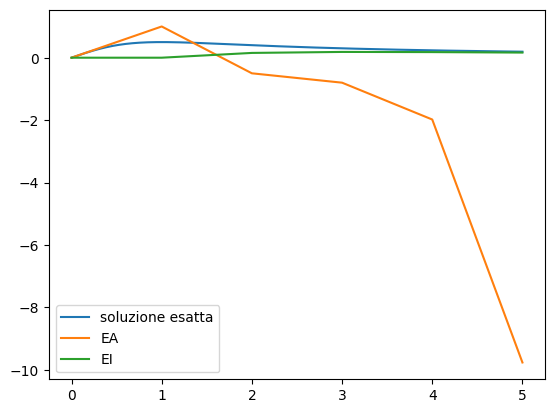

<Figure size 640x480 with 0 Axes>

In [33]:
h=1

t_ea, u_ea= eulero_avanti(f, t0, tmax, y0, h)
t_ei, u_ei=eulero_indietro(f, t0, tmax, y0, h)

plt.figure()
plt.plot(x_grid, u_ex(x_grid), label='soluzione esatta')
plt.plot(t_ea, u_ea, label='EA')
plt.plot(t_ei, u_ei, label='EI')
plt.legend()
plt.figure()

In [35]:
#come vediamo dal grafico, il metodo EI converge alla soluzione esatta, mentre il metodo EE non converge alla soluzione.
#la soluzione è diminuire h in modo da soddisfare la condizione di a-stabilità di EE

##### **Soluzione.**

Possiamo verificare se i due schemi risultano assolutamente stabili o presentano oscillazioni tramite il seguente codice.

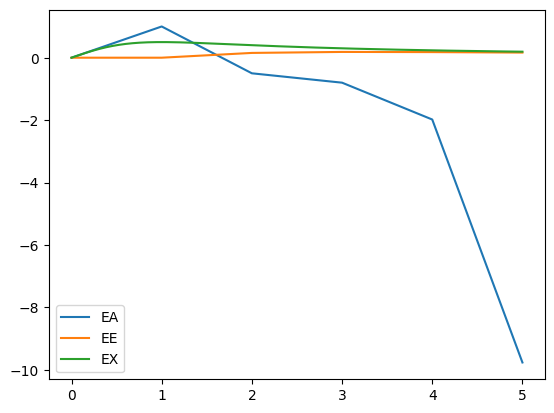

In [ ]:
h = 1

# calcolo della soluzione numerica con i due metodi
t_ea, u_ea = eulero_avanti(f, t0, t_max, y0, h=h)
t_ei, u_ei = eulero_indietro(f, t0, t_max, y0, h=h)

# plot delle soluzioni
plt.plot(t_ea, u_ea, label="EA")
plt.plot(t_ei, u_ei, label="EE")
plt.plot(t, y(t), label="EX")
plt.legend()

plt.show()

Notiamo che, come ci si aspetta, il metodo di Eulero in avanti presenta una criticità essendo condizionatamente assolutamente stabile. Tale condizione risulta non verificata date le oscillazioni e il fatto che la soluzione diverge. Una possibile strategia migliorativa è quella di diminuire l'intervallo di tempo $h$ in modo da rientrare nella regione di assoluta stabilità dello schema.

# **Esercizio 3 (10 punti)**

Si considerino i dati nel blocco di codice seguente che genera 20 coppie di dati e li salva nella variabile `data`.

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from numpy import interp  # interpolazione lineare a tratti

np.random.seed(1)
N = 20
vals = np.linspace(0, 10, N)
noise = np.random.normal(0, 0.1, N)
# dati generati
data = np.sin(vals) + noise

#### **(3a) (3 punti) [T]**

Presentare l'interpolazione Lagrangiana su nodi equispaziati, specificando proprietà e limitazioni. Proporre strategie migliorative.

In [37]:
#dati n+1 coppie di punti (xi,yi) cerco un polinomio di grado n, chiamato pi_n appartenente allo spazio dei polinomi fino al grado n e che 
#passi per gli n+1 punti, ovvero che soddisfi: pi_n(xi)=yi.
#devo definire quindi un polinomio che sia lo span di una base, per fare in modo di dover risolvere un sistema diagonale scelgo come base quella deu
#polinomi di Lagrange: Li(xk)=1 se k=i o 0 se k diverso i --> Li(x)=prod((x-xj)/(xi-xj))
#il polinomio interpolante sarà quindi dato da una combinazione lineare di questi polinomi e cioé:
#Pi_n(x)=somma per i da 0 a n di Li(x)*yi

#I polinomi di Lagrange sono utilizzati su nodi equispazioni, il problema di questa applicazione risiede nel fatto che aumentando il numero di nodi
#si verifica il fenomeno di Runge, ossia sebbene al centro dell'intervallo l'interpolazione migliori, agli estremi aumentano le oscillazioni

#inoltre un'ulteriore problema è la stabilità. infatti se si ha una perturbazione dei dati iniziali di cui conoscevamo il polinomio pi, ci
#chiediamo di quanto varia tale polinomio perturbato e quindi quanto vale la differenza tra tali polinomi. Tale errore è proporzionale al massimo della 
#perturbazione secondo una costante detta Costante di Lebesgue che esplode quando n aumenta, perdendo quindi la stabilità dell'interpolazione

#per risolvere tale problema si possono sostituire i nodi equispaziati con i nodi di Chebichev- Gauss- Lobatto


##### **Soluzione.**

Date $n+1$ coppie di punti $(x_i, y_i)$ distinte, per $i=0, \ldots, n$, cerco un
polinomio di grado $n$ chiamato $\pi_n \in \mathbb{P}^n$, con $\mathbb{P}^n$
lo spazio dei polinomi fino al grado $n$, che passi per gli $n+1$ punti, ovvero,
tale che soddisfi
\begin{gather*}
    \pi_n(x_i) = y_i \quad i=0,\ldots,n.
\end{gather*}
Definisco quindi per ogni $i=0,\ldots,n$ un polinomio $\mathcal{L}_i$ di
grado $n$ con le seguenti caratteristiche:
\begin{gather*}
    \mathcal{L}_i(x_k) =
    \begin{cases}
        1 & \text{se } k=i\\
        0 & \text{se } k \neq i
    \end{cases}
    \quad \rightarrow \quad
    \mathcal{L}_i(x) = \prod_{j=0, j\neq i}^n \frac{x-x_j}{x_i-x_j}
\end{gather*}
tali polinomi sono detti polinomi caratteristici di Lagrange.

Date le proprietà dei polinomi di Lagrange, allora possiamo costruire
l'interpolante polinomiale $\pi_n(x)$ tale che $\pi_n(x_i) = y_i$ nel
seguente modo
\begin{gather*}
    \pi_n(x) = \sum_{i=0}^n y_i \mathcal{L}_i(x),
\end{gather*}
detto interpolante polinomiale Lagrangiano.

Nel caso di nodi equispaziati abbiamo la seguente stima di stabilità per l'errore
\begin{gather*}
    \Vert {\Pi_n f - \Pi_n \widetilde{f}}\Vert_\infty
    \leq \max_{i=0,\ldots,n} \vert{f(x_i) - \widetilde{f}(x_i)}\vert \max_{x\in I}
    \sum_{i=0}^n \vert{\mathcal{L}_i(x)}\vert
\end{gather*}
L'ultimo termine, che non dipende da $f$ ma solo dai valori dei $\mathcal{L}_i$ nei
nodi $x_i$, è detta costante di Lebesgue e, per nodi equispaziati,  è data da
\begin{gather*}
    \Lambda_n =  \max_{x\in I}\sum_{i=0}^n \vert{\mathcal{L}_i(x)}\vert \approx \frac{2^{n+1}}{e n
        (\log n+\gamma)}
\end{gather*}
tale costante diverge per $n \rightarrow \infty$ e quindi il metodo non risulta stabile, fenomeno di Runge. Una strategia per evitare questo problema è considerare i nodi di Chebychev-Gauss-Lobatto la cui costante di Lebesgue è data da
\begin{gather*}
    \Lambda_n < \frac{2}{\pi} \log n
\end{gather*}

#### **(3b) (3 punti) [P]**  

Calcolare l'interpolante polinomiale lagrangiano sfruttando le function di *numpy* *polyfit* e *polyval*. Rappresentare graficamente i dati insieme all'interpolante polinomiale Lagrangiano. Che fenomeno si osserva?

C:\Users\aless\AppData\Local\Temp\ipykernel_4396\3155238627.py:1: RankWarning: Polyfit may be poorly conditioned
  p=np.polyfit(vals, data, N+1)


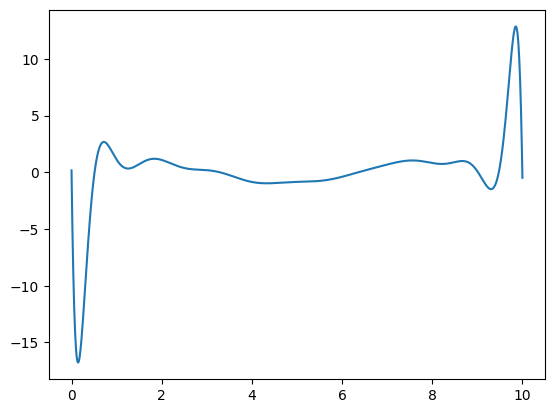

In [38]:
p=np.polyfit(vals, data, N+1)
y=lambda x: np.polyval(p,x)

xx=np.linspace(0,10, 1000)
plt.figure()
plt.plot(xx,y(xx))
plt.show()



In [39]:
#osserviamo il fenomeno di Runge, ossia l'oscillazione del polinomio agli estremi

##### **Soluzione.**   

Il codice per riprodurre la soluzione è il seguente.

/home/anna/.local/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3398: RankWarning: Polyfit may be poorly conditioned
  exec(code_obj, self.user_global_ns, self.user_ns)


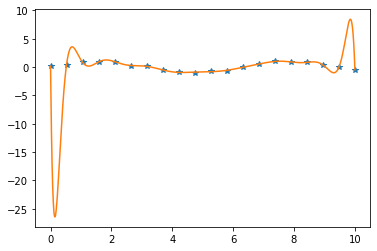

In [2]:
# costruzione dell'interpolante polinomiale
p = np.polyfit(vals, data, deg=N - 1)
p_I = lambda x: np.polyval(p, x)

# rappresentazione grafica dell'interpolante e dei dati
xx = np.linspace(0, 10, 1000)
plt.plot(vals, data, "*")
plt.plot(xx, p_I(xx))
plt.show()

Dato che i punti sono stati generati in maniera equispaziata notiamo che ai bordi l'interpolazione è poco accurata, che è appunto di fenomeno di Runge.

#### **(3c) (2 punti) [P]**  

Rappresentare graficamente i dati insieme all'interpolante lineare a tratti, calcolata usando la function *interp* di *numpy*. Che fenomeno si osserva?

In [40]:
help(interp)

Help on method descriptor interp in module numpy:

interp(x, xp, fp, left=None, right=None, period=None)
    One-dimensional linear interpolation for monotonically increasing sample points.

    Returns the one-dimensional piecewise linear interpolant to a function
    with given discrete data points (`xp`, `fp`), evaluated at `x`.

    Parameters
    ----------
    x : array_like
        The x-coordinates at which to evaluate the interpolated values.

    xp : 1-D sequence of floats
        The x-coordinates of the data points, must be increasing if argument
        `period` is not specified. Otherwise, `xp` is internally sorted after
        normalizing the periodic boundaries with ``xp = xp % period``.

    fp : 1-D sequence of float or complex
        The y-coordinates of the data points, same length as `xp`.

    left : optional float or complex corresponding to fp
        Value to return for `x < xp[0]`, default is `fp[0]`.

    right : optional float or complex corresponding to 

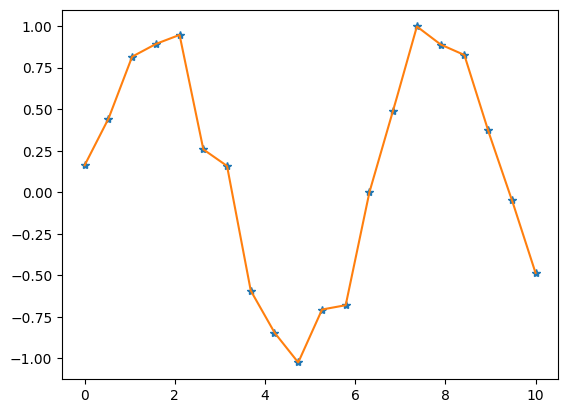

In [41]:
spline_lineare= lambda x: interp(x, vals, data)

xx=np.linspace(0,10, 1000)
plt.plot(vals, data, '*')
plt.plot(xx, spline_lineare(xx))
plt.show()


##### **Soluzione.**

Il codice per riprodurre la soluzione è il seguente.

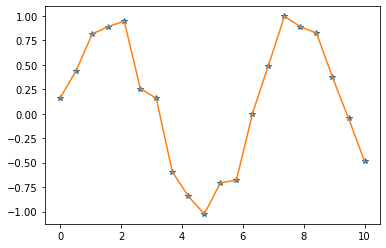

In [3]:
spline_lineare = lambda x: interp(x, vals, data)

# rappresentazione grafica dell'interpolante e dei dati
xx = np.linspace(0, 10, 1000)
plt.plot(vals, data, "*")
plt.plot(xx, spline_lineare(xx))
plt.show()

Essendo un'interpolazione lineare a tratti non notiamo più il fenomeno di Runge.

#### **(3d) (2 punti) [P]**

Rappresentare graficamente i dati insieme all'approssimante ai minimi quadrati di grado m = 10. Che fenomeno si osserva?

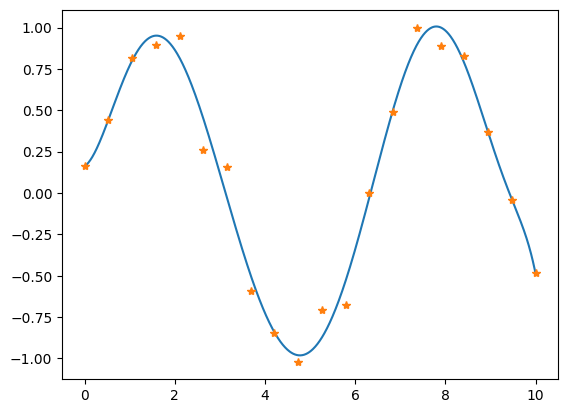

In [44]:
p_minq=np.polyfit(vals, data, 10)
y_minq=lambda x: np.polyval(p_minq, x)

xx=np.linspace(0,10,1000)
plt.figure()
plt.plot(xx, y_minq(xx))
plt.plot(vals, data, '*')
plt.show()

##### **Soluzione.**

Il codice per riprodurre la soluzione è il seguente.

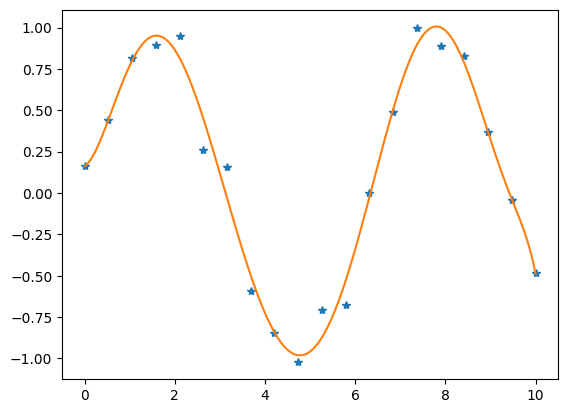

In [30]:
p_minq = np.polyfit(vals, data, deg=10)
minq = lambda x: np.polyval(p_minq, x)

# rappresentazione grafica dell'interpolante e dei dati
xx = np.linspace(0, 10, 1000)
plt.plot(vals, data, "*")
plt.plot(xx, minq(xx))
plt.show()

L'approssimante ai minimi quadrati approssima bene i dati e non si verificano fenomeni oscillatori.